**Since the internal cycle counter did not provide a clearly interpretable full signal cycle length, the static signal timing approximation was derived directly from the observed second-by-second signal-state pattern. Consecutive identical signal-state combinations were compressed into phase blocks, and recurring phase blocks were analysed to identify representative phase durations.**

**LSA10 Phase Pattern Extractor - Morning**

In [5]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 5: LSA10 PHASE PATTERN EXTRACTOR
# ============================================================
# Purpose:
# - Read LSA10 signal-state JSON files
# - Select one representative scenario
# - Extract K1, K2, K3, K4, K5 states second by second
# - Compress consecutive identical signal-state combinations
# - Create phase block table for static SUMO approximation
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA10_719612af-2487-4771-941f-534a4f568272"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_NAME = "weekday_morning"
TARGET_DATE = "2026-03-10"
WINDOW_START = "08:00:00"
WINDOW_END = "09:00:00"

OUT_CSV = OUT_DIR / f"LSA10_phase_blocks_{SCENARIO_NAME}.csv"
OUT_XLSX = OUT_DIR / f"LSA10_phase_blocks_{SCENARIO_NAME}.xlsx"

SIGNAL_GROUPS = {
    "K1": 1,    # West
    "K2": 2,    # North_West
    "K3": 3,    # North_East
    "K4": 4,    # East
    "K5": 19,   # South
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5"]

# ============================================================
# PARSE SIGNAL DATA
# ============================================================

rows = []

for json_path in sorted(SIGNAL_DIR.glob("*.json")):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_utc = pd.to_datetime(data["start"])

    for value in data.get("values", []):
        timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
        timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

        date_local = str(timestamp_local.date())
        time_local = timestamp_local.time()

        if date_local != TARGET_DATE:
            continue

        start_t = pd.to_datetime(WINDOW_START).time()
        end_t = pd.to_datetime(WINDOW_END).time()

        if not (start_t <= time_local < end_t):
            continue

        sig_states = {
            item["id"]: item["sgState"]
            for item in value.get("sigState", [])
        }

        node_info = value.get("nodes", [{}])[0]

        row = {
            "timestamp_local": timestamp_local,
            "date": date_local,
            "time": time_local,
            "program": node_info.get("program"),
            "stage": node_info.get("stage"),
            "cycCnt": node_info.get("cycCnt"),
            "stgCnt": node_info.get("stgCnt"),
            "stgTran": node_info.get("stgTran"),
        }

        for group_name, signal_id in SIGNAL_GROUPS.items():
            row[group_name] = sig_states.get(signal_id)

        rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No signal data found. Check folder, date, and time window.")

df = df.sort_values("timestamp_local").reset_index(drop=True)

# ============================================================
# CREATE PATTERN K1-K2-K3-K4-K5
# ============================================================

for col in GROUP_COLUMNS:
    if df[col].isna().any():
        raise ValueError(
            f"{col} contains missing values. Check SIGNAL_GROUPS mapping."
        )
    df[col] = df[col].astype(int)

df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)

# ============================================================
# COMPRESS CONSECUTIVE IDENTICAL PATTERNS
# ============================================================

df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

phase_blocks = (
    df.groupby("block_id")
    .agg(
        start_time=("timestamp_local", "first"),
        end_time=("timestamp_local", "last"),
        date=("date", "first"),
        K1=("K1", "first"),
        K2=("K2", "first"),
        K3=("K3", "first"),
        K4=("K4", "first"),
        K5=("K5", "first"),
        pattern=("pattern", "first"),
        stage=("stage", "first"),
        program=("program", "first"),
        n_seconds=("pattern", "count"),
    )
    .reset_index()
)

phase_blocks["duration_s"] = phase_blocks["n_seconds"]

phase_blocks_excel = phase_blocks.copy()
phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

# ============================================================
# PATTERN SUMMARY
# ============================================================

pattern_summary = (
    phase_blocks
    .groupby(["pattern", "K1", "K2", "K3", "K4", "K5"])
    .agg(
        occurrences=("block_id", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
    )
    .reset_index()
    .sort_values("total_duration_s", ascending=False)
)

# ============================================================
# SAVE OUTPUTS
# ============================================================

phase_blocks_excel.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

df_excel = df.copy()
df_excel["timestamp_local"] = df_excel["timestamp_local"].astype(str)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    phase_blocks_excel.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    df_excel.to_excel(writer, sheet_name="Secondwise_K1_K5", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nTop recurring patterns:")
print(pattern_summary.head(20))

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_phase_blocks_weekday_morning.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_phase_blocks_weekday_morning.xlsx

Top recurring patterns:
      pattern  K1  K2  K3  K4  K5  occurrences  total_duration_s  \
16  4-2-2-4-2   4   2   2   4   2           41              1520   
11  2-4-4-2-2   2   4   4   2   2           40               580   
2   2-2-2-2-4   2   2   2   2   4           37               351   
0   2-2-2-2-2   2   2   2   2   2          117               301   
15  4-2-2-2-2   4   2   2   2   2            9               164   
1   2-2-2-2-3   2   2   2   2   3           37               111   
9   2-3-4-2-2   2   3   4   2   2           31                93   
6   2-2-3-2-2   2   2   3   2   2           31                93   
4   2-2-2-3-2   2   2   2   3   2           37                74   
14  3-2-2-4-2   3   2   2   4   2        

For LSA10, the representative phase structure was derived from the second-by-second signal-state data for the weekday morning scenario. In contrast to LSA16, five signal groups were considered: K1, K2, K3, K4, and K5. Consecutive identical signal-state combinations were compressed into phase blocks, and the recurring patterns were evaluated based on their occurrence frequency and average duration.

The dominant phase pattern was `4-2-2-4-2`, with an average duration of approximately 37 s. This indicates a main release phase for the west and east approaches. The second major release pattern was `2-4-4-2-2`, representing the north-west and north-east signal groups, with an average duration of approximately 15 s. In addition, the pattern `2-2-2-2-4` appeared as a south approach release phase with an average duration of approximately 9 s.

The remaining patterns mainly represent transition or clearance states, with short average durations between approximately 1 and 3 s. Overall, the extracted pattern structure provides a suitable basis for deriving an approximate static signal timing plan for SUMO.

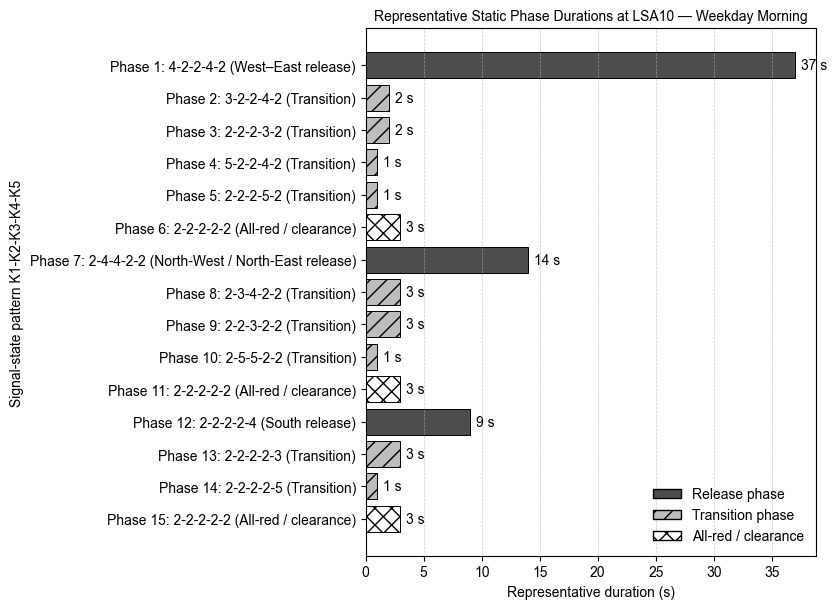

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_morning_accessible.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_morning_accessible.svg

Representative static phase table:
    phase    pattern  phase_type                      description  \
0       1  4-2-2-4-2     Release                West–East release   
1       2  3-2-2-4-2  Transition                       Transition   
2       3  2-2-2-3-2  Transition                       Transition   
3       4  5-2-2-4-2  Transition                       Transition   
4       5  2-2-2-5-2  Transition                       Transition   
5       6  2-2-2-2-2   Clearance              All-red / clearance   
6       7  2-4-4-2-2     Release  North-West / North-East release   
7       8  2-3-4-2-2  Transition                       Transition   
8       9  2-2-3-2-2  Transition  

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 5B: LSA10 REPRESENTATIVE PHASE DURATION FIGURE
# ============================================================
# Purpose:
# - Read LSA10 phase block output
# - Create a thesis-style horizontal bar chart
# - Distinguish release, transition, and clearance phases
# - Avoid red/green color dependency
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)

IN_XLSX = BASE_DIR / "LSA10_phase_blocks_weekday_morning.xlsx"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "LSA10_representative_phase_durations_weekday_morning_accessible.png"
OUT_SVG = OUT_DIR / "LSA10_representative_phase_durations_weekday_morning_accessible.svg"

# ============================================================
# LOAD DATA
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE FOR LSA10
# ============================================================
# Pattern order: K1-K2-K3-K4-K5
#
# K1 = West
# K2 = North_West
# K3 = North_East
# K4 = East
# K5 = South
# ============================================================

representative_rows = [
    {
        "phase": 1,
        "pattern": "4-2-2-4-2",
        "phase_type": "Release",
        "description": "West–East release"
    },
    {
        "phase": 2,
        "pattern": "3-2-2-4-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 3,
        "pattern": "2-2-2-3-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 4,
        "pattern": "5-2-2-4-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 5,
        "pattern": "2-2-2-5-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 6,
        "pattern": "2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 7,
        "pattern": "2-4-4-2-2",
        "phase_type": "Release",
        "description": "North-West / North-East release"
    },
    {
        "phase": 8,
        "pattern": "2-3-4-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 9,
        "pattern": "2-2-3-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 10,
        "pattern": "2-5-5-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 11,
        "pattern": "2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 12,
        "pattern": "2-2-2-2-4",
        "phase_type": "Release",
        "description": "South release"
    },
    {
        "phase": 13,
        "pattern": "2-2-2-2-3",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 14,
        "pattern": "2-2-2-2-5",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 15,
        "pattern": "2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
]

df = pd.DataFrame(representative_rows)

df["representative_duration_s"] = df["pattern"].map(duration_lookup)

missing = df[df["representative_duration_s"].isna()]
if not missing.empty:
    raise ValueError(
        "Some representative patterns were not found in Pattern_Summary:\n"
        + str(missing[["phase", "pattern", "description"]])
    )

df["representative_duration_s"] = df["representative_duration_s"].astype(int)

# ============================================================
# ACCESSIBLE STYLE
# ============================================================

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase"
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase"
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance"
    },
}

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8.4, 6.2))

y_labels = [
    f"Phase {row.phase}: {row.pattern} ({row.description})"
    for _, row in df.iterrows()
]

for i, row in df.iterrows():
    style = STYLE[row["phase_type"]]

    ax.barh(
        y_labels[i],
        row["representative_duration_s"],
        color=style["color"],
        edgecolor="black",
        linewidth=0.7,
        hatch=style["hatch"]
    )

ax.set_title("Representative Static Phase Durations at LSA10 — Weekday Morning")
ax.set_xlabel("Representative duration (s)")
ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

for i, row in df.iterrows():
    ax.text(
        row["representative_duration_s"] + 0.5,
        i,
        f"{row['representative_duration_s']} s",
        va="center"
    )

ax.invert_yaxis()

legend_handles = []
legend_labels = []

for phase_type, style in STYLE.items():
    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"]
    )
    legend_handles.append(handle)
    legend_labels.append(style["label"])

ax.legend(
    legend_handles,
    legend_labels,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_SVG, bbox_inches="tight")
plt.show()

print("Saved:")
print(OUT_PNG)
print(OUT_SVG)

print("\nRepresentative static phase table:")
print(df[[
    "phase",
    "pattern",
    "phase_type",
    "description",
    "representative_duration_s"
]])

print("\nApproximate representative cycle length:")
print(df["representative_duration_s"].sum(), "seconds")

In [ ]:
from pathlib import Path
import pandas as pd
from xml.dom import minidom
import xml.etree.ElementTree as ET

# ============================================================
# CODE 6: LSA10 STATIC SUMO TLS PROGRAM GENERATOR
# ============================================================
# Purpose:
# - Read representative phase pattern durations
# - Convert K1-K2-K3-K4-K5 signal-state patterns into SUMO TLS states
# - Use NetEdit TLS link index mapping
# - Create a static SUMO additional file for LSA16
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation"
)

IN_XLSX = BASE_DIR / "LSA10_phase_blocks_weekday_morning.xlsx"

OUT_XML = BASE_DIR / "LSA10_static_tls_weekday_morning.add.xml"
OUT_PHASE_TABLE_CSV = BASE_DIR / "LSA10_static_tls_weekday_morning_phase_table.csv"

# IMPORTANT:
# Replace this with the exact SUMO TLS id from NetEdit if different.
TLS_ID = "9876"

PROGRAM_ID = "derived_weekday_morning"

# ============================================================
# SUMO LINK INDEX TO SIGNAL GROUP MAPPING
# ============================================================
# SUMO TLS state string order:
#
# index 0  -> East right/straight   -> K4
# index 1  -> East right/straight   -> K4
# index 2  -> East right/straight   -> K4
# index 3  -> East Straight         -> K4
# index 4  -> South multimovement   -> K5
# index 5  -> South multimovement   -> K5
# index 6  -> South multimovement   -> K5
# index 7  -> South multimovement   -> K5
# index 8  -> West Straight/Right   -> K1
# index 9  -> West Straight/Right   -> K1
# index 10 -> West Straight/Right   -> K1
# index 11 -> North_West Straight/Right -> K2
# index 12 -> North_West Straight/Right -> K2
# index 13 -> North_West Straight/Left -> K2
# index 14 -> North_West Straight/Left -> K2
# index 15 -> North_West Straight/Left -> K2
# index 16 -> North_East Right -> K3


# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K4",
    1: "K4",
    2: "K4",
    3: "K4",
    4: "K5",
    5: "K5",
    6: "K5",
    7: "K5",
    8: "K1",
    9: "K1",
    10: "K1",
    11: "K2",
    12: "K2",
    13: "K2",
    14: "K2",
    15: "K2",
    16: "K3",
}

# ============================================================
# SIGNAL STATE TO SUMO TLS CHARACTER
# ============================================================

def sgstate_to_sumo_char(sg_state):
    """
    Converts SI PL sgState to SUMO TLS character.

    4 -> G : protected green / release
    3,5 -> y : transition / yellow-like state
    2 -> r : red / blocked
    """
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    """
    Converts pattern like '2-4-2-4' for K1-K2-K3-K4
    into SUMO TLS state string according to LINK_INDEX_TO_GROUP.
    """
    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k4),

        
    }

    state_chars = []

    for idx in sorted(LINK_INDEX_TO_GROUP.keys()):
        group = LINK_INDEX_TO_GROUP[idx]
        state_chars.append(group_state[group])

    return "".join(state_chars)

# ============================================================
# LOAD REPRESENTATIVE PATTERN SUMMARY
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE
# ============================================================
# Based on weekday morning recurring signal-state structure.
# 2-2-2-2 appears twice as clearance.
# ============================================================

representative_phases = [
    {
        "phase": 1,
        "pattern": "2-2-2-4",
        "description": "East-only release",
    },
    {
        "phase": 2,
        "pattern": "2-4-2-4",
        "description": "East-West release",
    },
    {
        "phase": 3,
        "pattern": "2-3-2-4",
        "description": "Transition",
    },
    {
        "phase": 4,
        "pattern": "2-5-2-5",
        "description": "Transition",
    },
    {
        "phase": 5,
        "pattern": "2-2-2-2",
        "description": "All-red / clearance",
    },
    {
        "phase": 6,
        "pattern": "4-2-4-2",
        "description": "North-South release",
    },
    {
        "phase": 7,
        "pattern": "3-2-3-2",
        "description": "Transition",
    },
    {
        "phase": 8,
        "pattern": "5-2-5-2",
        "description": "Transition",
    },
    {
        "phase": 9,
        "pattern": "2-2-2-2",
        "description": "All-red / clearance",
    },
]

phase_rows = []

for phase in representative_phases:
    pattern = phase["pattern"]

    if pattern not in duration_lookup:
        raise ValueError(f"Pattern {pattern} not found in Pattern_Summary.")

    duration = duration_lookup[pattern]
    sumo_state = pattern_to_sumo_state(pattern)

    k1, k2, k3, k4 = [int(x) for x in pattern.split("-")]

    phase_rows.append({
        "phase": phase["phase"],
        "pattern_K1_K2_K3_K4_K5": pattern,
        "K1": k1,
        "K2": k2,
        "K3": k3,
        "K4": k4,
        "K5": k5,
        "duration_s": duration,
        "sumo_state": sumo_state,
        "description": phase["description"],
    })

phase_table = pd.DataFrame(phase_rows)

# ============================================================
# CREATE SUMO TLS XML
# ============================================================

additional = ET.Element("additional")

tl_logic = ET.SubElement(
    additional,
    "tlLogic",
    {
        "id": TLS_ID,
        "type": "static",
        "programID": PROGRAM_ID,
        "offset": "0",
    }
)

for _, row in phase_table.iterrows():
    ET.SubElement(
        tl_logic,
        "phase",
        {
            "duration": str(int(row["duration_s"])),
            "state": row["sumo_state"],
        }
    )

# Pretty print XML
rough_string = ET.tostring(additional, encoding="utf-8")
parsed = minidom.parseString(rough_string)
pretty_xml = parsed.toprettyxml(indent="    ")

with open(OUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

phase_table.to_csv(OUT_PHASE_TABLE_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# PRINT RESULTS
# ============================================================

print("Saved SUMO TLS additional file:")
print(OUT_XML)

print("\nSaved phase table:")
print(OUT_PHASE_TABLE_CSV)

print("\nGenerated static phase table:")
print(phase_table)

print("\nSUMO state string length:")
print(len(phase_table.iloc[0]["sumo_state"]))

print("\nApproximate static cycle length:")
print(phase_table["duration_s"].sum(), "seconds")

Saved SUMO TLS additional file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_static_tls_weekday_morning.add.xml

Saved phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA16_saturation\LSA16_static_tls_weekday_morning_phase_table.csv

Generated static phase table:
   phase pattern_K1_K2_K3_K4  K1  K2  K3  K4            K7  duration_s  \
0      1             2-2-2-4   2   2   2   4  permissive_g          21   
1      2             2-4-2-4   2   4   2   4  permissive_g          27   
2      3             2-3-2-4   2   3   2   4  permissive_g           3   
3      4             2-5-2-5   2   5   2   5  permissive_g           1   
4      5             2-2-2-2   2   2   2   2  permissive_g           4   
5      6             4-2-4-2   4   2   4   2  permissive_g          23   
6      7             3-2-3-2   3   2   3   2  permissive_g           3   
7      8             5-2-5-2   5   2   5   2  permissive_g           1   
8      9   

extract phase patterns for all 4 representative scenarios

create one Excel with phase blocks + summaries

create one static TLS XML per scenario

create one phase-duration graph per scenario


Found signal JSON files: 320
Parsed rows: 3371711

Processing scenario: weekday_morning

Available patterns:
      pattern  occurrences  total_duration_s  mean_duration_s
16  4-2-2-4-2           41              1520        37.073171
11  2-4-4-2-2           40               580        14.500000
2   2-2-2-2-4           37               351         9.486486
0   2-2-2-2-2          117               301         2.572650
15  4-2-2-2-2            9               164        18.222222
1   2-2-2-2-3           37               111         3.000000
9   2-3-4-2-2           31                93         3.000000
6   2-2-3-2-2           31                93         3.000000
4   2-2-2-3-2           37                74         2.000000
14  3-2-2-4-2           37                74         2.000000
13  3-2-2-3-2           40                46         1.150000
12  2-5-5-2-2           40                40         1.000000
3   2-2-2-2-5           37                37         1.000000
19  5-2-2-4-2          

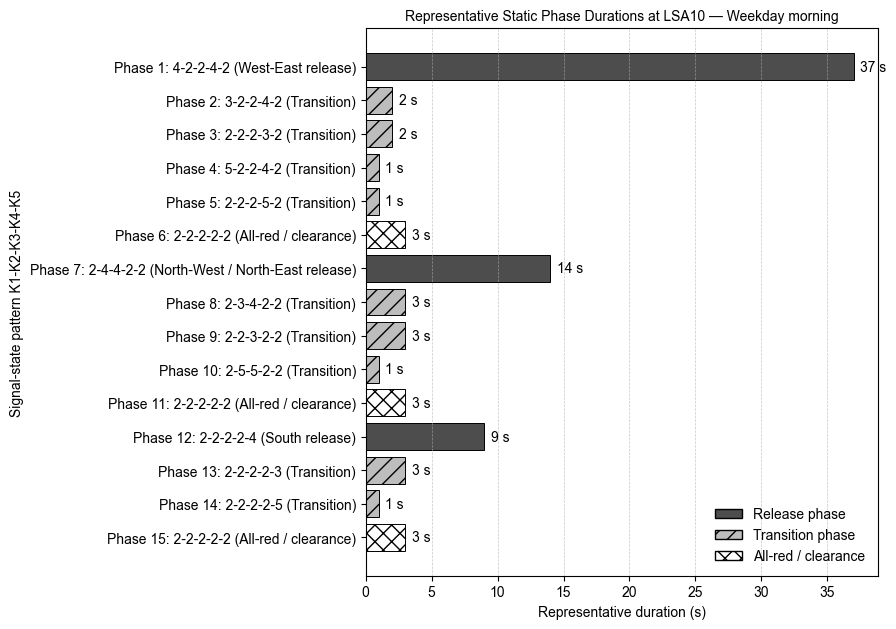

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekday_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekday_morning_phase_table.csv
SUMO state string length: 17
Approximate static cycle length: 86 s

Processing scenario: weekday_evening

Available patterns:
      pattern  occurrences  total_duration_s  mean_duration_s
16  4-2-2-4-2           41              1416        34.536585
11  2-4-4-2-2           40               523        13.075000
2   2-2-2-2-4           40               388         9.700000
0   2

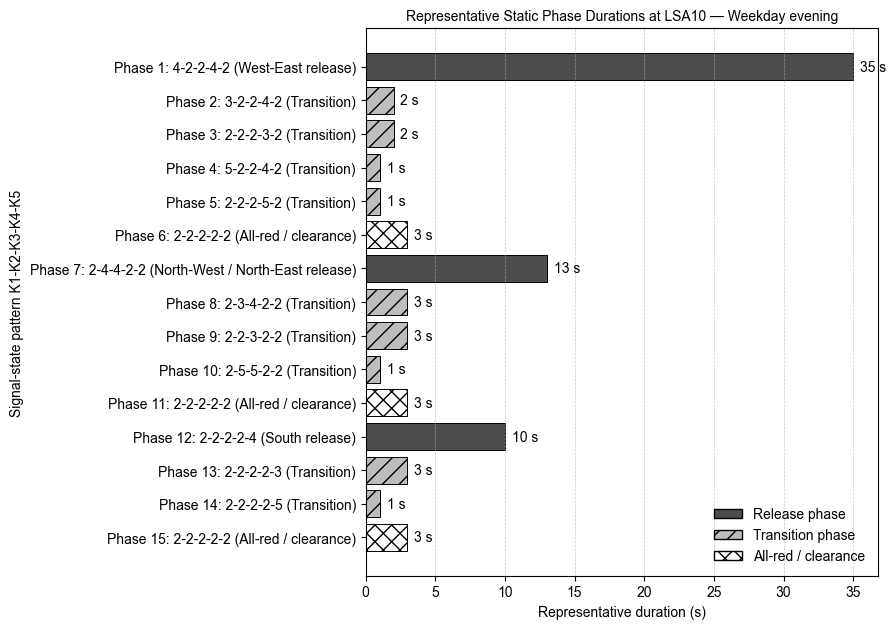

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekday_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekday_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekday_evening_phase_table.csv
SUMO state string length: 17
Approximate static cycle length: 84 s

Processing scenario: weekend_morning

Available patterns:
      pattern  occurrences  total_duration_s  mean_duration_s
16  4-2-2-4-2           40              1784        44.600000
11  2-4-4-2-2           38               611        16.078947
2   2-2-2-2-4           30               293         9.766667
0   2

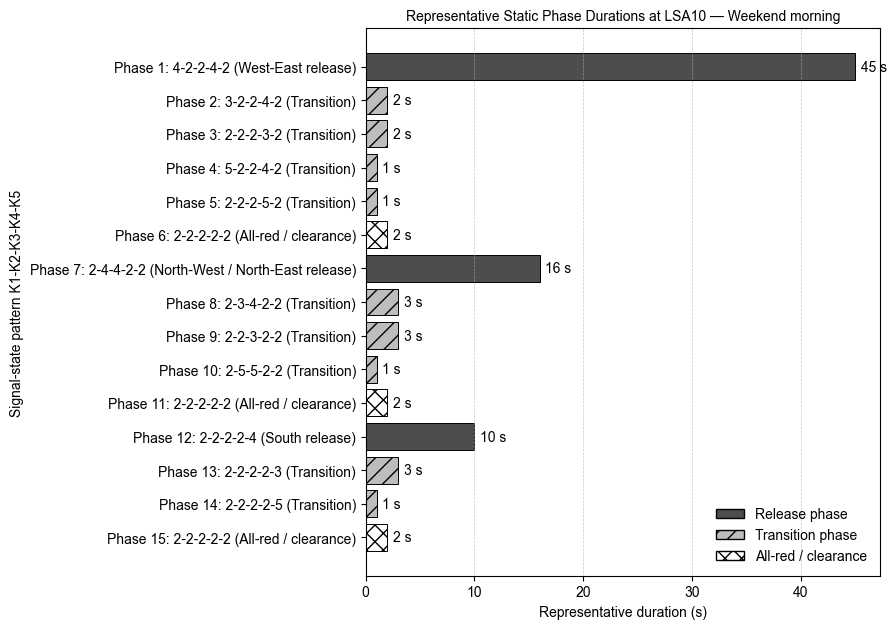

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekend_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekend_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekend_morning_phase_table.csv
SUMO state string length: 17
Approximate static cycle length: 94 s

Processing scenario: weekend_evening

Available patterns:
      pattern  occurrences  total_duration_s  mean_duration_s
16  4-2-2-4-2           40              1776        44.400000
11  2-4-4-2-2           38               492        12.947368
2   2-2-2-2-4           33               308         9.333333
0   2

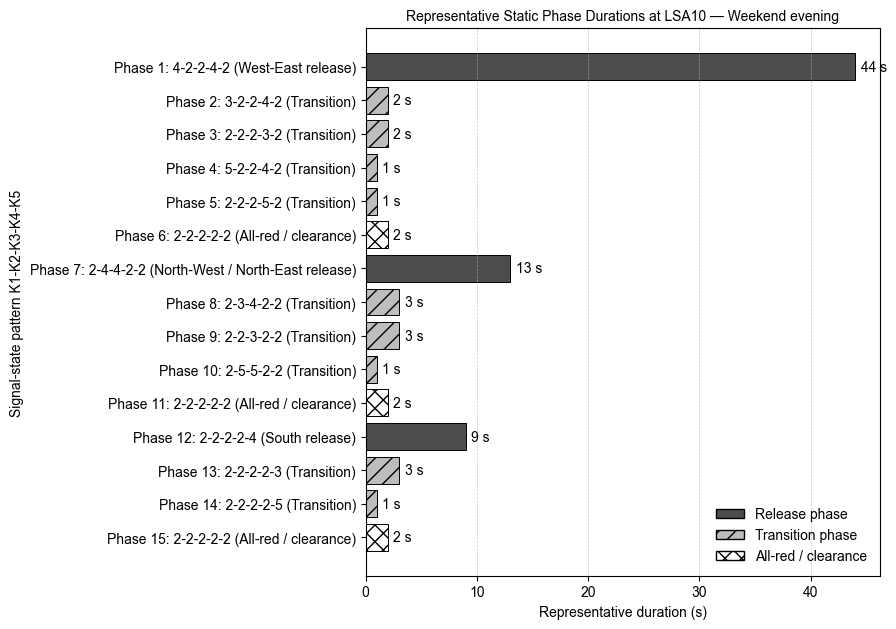

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_weekend_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekend_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs\LSA10_static_tls_weekend_evening_phase_table.csv
SUMO state string length: 17
Approximate static cycle length: 89 s

DONE
Saved combined Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_all_scenarios_phase_patterns_and_static_tls.xlsx

Saved TLS XML files in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\static_tls_programs

Saved figures in:
C:\Users\mogul\

In [7]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from xml.dom import minidom

# ============================================================
# CODE 7: LSA10 STATIC TLS PROGRAMS + PHASE GRAPHS FOR ALL SCENARIOS
# ============================================================
# Purpose:
# - Extract phase patterns for all representative scenarios
# - Build representative static phase tables
# - Generate SUMO static TLS additional files
# - Create phase duration figures for each scenario
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA10_719612af-2487-4771-941f-534a4f568272"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TLS_DIR = OUT_DIR / "static_tls_programs"
TLS_DIR.mkdir(parents=True, exist_ok=True)

# Change this if the NetEdit TLS ID is different
TLS_ID = "tls_9873"

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-03-10",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekday morning",
    },
    "weekday_evening": {
        "date": "2026-03-23",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekday evening",
    },
    "weekend_morning": {
        "date": "2026-03-14",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekend morning",
    },
    "weekend_evening": {
        "date": "2026-03-22",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekend evening",
    },
}

SIGNAL_GROUPS = {
    "K1": 1,     # West
    "K2": 2,     # North_West
    "K3": 3,     # North_East
    "K4": 4,     # East
    "K5": 19,    # South
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5"]

# ============================================================
# SUMO LINK INDEX TO SIGNAL GROUP MAPPING
# ============================================================
# index 0  -> East right/straight        -> K4
# index 1  -> East right/straight        -> K4
# index 2  -> East right/straight        -> K4
# index 3  -> East straight              -> K4
# index 4  -> South multimovement        -> K5
# index 5  -> South multimovement        -> K5
# index 6  -> South multimovement        -> K5
# index 7  -> South multimovement        -> K5
# index 8  -> West straight/right        -> K1
# index 9  -> West straight/right        -> K1
# index 10 -> West straight/right        -> K1
# index 11 -> North_West straight/right  -> K2
# index 12 -> North_West straight/right  -> K2
# index 13 -> North_West straight/left   -> K2
# index 14 -> North_West straight/left   -> K2
# index 15 -> North_West straight/left   -> K2
# index 16 -> North_East right           -> K3
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K4",
    1: "K4",
    2: "K4",
    3: "K4",
    4: "K5",
    5: "K5",
    6: "K5",
    7: "K5",
    8: "K1",
    9: "K1",
    10: "K1",
    11: "K2",
    12: "K2",
    13: "K2",
    14: "K2",
    15: "K2",
    16: "K3",
}

# Pattern order: K1-K2-K3-K4-K5
REPRESENTATIVE_PHASE_SEQUENCE = [
    {"phase": 1,  "pattern": "4-2-2-4-2", "phase_type": "Release",    "description": "West-East release"},
    {"phase": 2,  "pattern": "3-2-2-4-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 3,  "pattern": "2-2-2-3-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 4,  "pattern": "5-2-2-4-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 5,  "pattern": "2-2-2-5-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 6,  "pattern": "2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 7,  "pattern": "2-4-4-2-2", "phase_type": "Release",    "description": "North-West / North-East release"},
    {"phase": 8,  "pattern": "2-3-4-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 9,  "pattern": "2-2-3-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 10, "pattern": "2-5-5-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 11, "pattern": "2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 12, "pattern": "2-2-2-2-4", "phase_type": "Release",    "description": "South release"},
    {"phase": 13, "pattern": "2-2-2-2-3", "phase_type": "Transition", "description": "Transition"},
    {"phase": 14, "pattern": "2-2-2-2-5", "phase_type": "Transition", "description": "Transition"},
    {"phase": 15, "pattern": "2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},
]

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase",
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase",
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance",
    },
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def sgstate_to_sumo_char(sg_state):
    """
    SI PL sgState -> SUMO state character.
    4    -> G : protected release
    3,5  -> y : transition
    2    -> r : red / blocked
    """
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    """
    Converts K1-K2-K3-K4-K5 pattern into SUMO TLS state string.
    """
    k1, k2, k3, k4, k5 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k5),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )


def save_sumo_tls_xml(phase_table, out_xml, program_id):
    additional = ET.Element("additional")

    tl_logic = ET.SubElement(
        additional,
        "tlLogic",
        {
            "id": TLS_ID,
            "type": "static",
            "programID": program_id,
            "offset": "0",
        }
    )

    for _, row in phase_table.iterrows():
        ET.SubElement(
            tl_logic,
            "phase",
            {
                "duration": str(int(row["duration_s"])),
                "state": row["sumo_state"],
            }
        )

    rough_string = ET.tostring(additional, encoding="utf-8")
    parsed = minidom.parseString(rough_string)
    pretty_xml = parsed.toprettyxml(indent="    ")

    with open(out_xml, "w", encoding="utf-8") as f:
        f.write(pretty_xml)


def plot_phase_durations(phase_table, scenario_name, scenario_label):
    out_png = FIG_DIR / f"LSA10_representative_phase_durations_{scenario_name}.png"
    out_svg = FIG_DIR / f"LSA10_representative_phase_durations_{scenario_name}.svg"

    fig, ax = plt.subplots(figsize=(9.0, 6.4))

    y_labels = [
        f"Phase {row.phase}: {row.pattern_K1_K2_K3_K4_K5} ({row.description})"
        for _, row in phase_table.iterrows()
    ]

    for i, row in phase_table.iterrows():
        style = STYLE[row["phase_type"]]

        ax.barh(
            y_labels[i],
            row["duration_s"],
            color=style["color"],
            edgecolor="black",
            linewidth=0.7,
            hatch=style["hatch"]
        )

        ax.text(
            row["duration_s"] + 0.5,
            i,
            f"{int(row['duration_s'])} s",
            va="center"
        )

    ax.set_title(f"Representative Static Phase Durations at LSA10 — {scenario_label}")
    ax.set_xlabel("Representative duration (s)")
    ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5")
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()

    legend_handles = []
    legend_labels = []

    for _, style in STYLE.items():
        handle = plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=style["color"],
            edgecolor="black",
            hatch=style["hatch"]
        )
        legend_handles.append(handle)
        legend_labels.append(style["label"])

    ax.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        loc="lower right"
    )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved figure:")
    print(out_png)
    print(out_svg)

# ============================================================
# PARSE ALL SIGNAL FILES ONCE
# ============================================================

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            row = {
                "timestamp_local": timestamp_local,
                "date": str(timestamp_local.date()),
                "time": timestamp_local.time(),
                "program": node_info.get("program"),
                "stage": node_info.get("stage"),
                "cycCnt": node_info.get("cycCnt"),
                "stgCnt": node_info.get("stgCnt"),
                "stgTran": node_info.get("stgTran"),
            }

            for group_name, signal_id in SIGNAL_GROUPS.items():
                row[group_name] = sig_states.get(signal_id)

            rows.append(row)

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise ValueError("No signal data parsed.")

print("Parsed rows:", len(df_all))

# ============================================================
# PROCESS EACH SCENARIO
# ============================================================

all_phase_blocks = []
all_pattern_summaries = []
all_static_phase_tables = []

for scenario_name, scenario in SCENARIOS.items():

    print("\n" + "=" * 70)
    print(f"Processing scenario: {scenario_name}")
    print("=" * 70)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    df = df_all[
        (df_all["date"] == scenario["date"]) &
        (df_all["time"] >= start_t) &
        (df_all["time"] < end_t)
    ].copy()

    if df.empty:
        print(f"No data found for {scenario_name}. Skipping.")
        continue

    df = df.sort_values("timestamp_local").reset_index(drop=True)

    for col in GROUP_COLUMNS:
        if df[col].isna().any():
            missing_count = df[col].isna().sum()
            raise ValueError(f"{col} has {missing_count} missing values. Check signal_id mapping.")
        df[col] = df[col].astype(int)

    df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)

    df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

    phase_blocks = (
        df.groupby("block_id")
        .agg(
            start_time=("timestamp_local", "first"),
            end_time=("timestamp_local", "last"),
            date=("date", "first"),
            K1=("K1", "first"),
            K2=("K2", "first"),
            K3=("K3", "first"),
            K4=("K4", "first"),
            K5=("K5", "first"),
            pattern=("pattern", "first"),
            stage=("stage", "first"),
            program=("program", "first"),
            n_seconds=("pattern", "count"),
        )
        .reset_index()
    )

    phase_blocks["duration_s"] = phase_blocks["n_seconds"]
    phase_blocks["scenario"] = scenario_name
    phase_blocks["window_start"] = scenario["start"]
    phase_blocks["window_end"] = scenario["end"]

    pattern_summary = (
        phase_blocks
        .groupby(["scenario", "pattern", "K1", "K2", "K3", "K4", "K5"])
        .agg(
            occurrences=("block_id", "count"),
            total_duration_s=("duration_s", "sum"),
            mean_duration_s=("duration_s", "mean"),
            median_duration_s=("duration_s", "median"),
            min_duration_s=("duration_s", "min"),
            max_duration_s=("duration_s", "max"),
        )
        .reset_index()
        .sort_values("total_duration_s", ascending=False)
    )

    duration_lookup = {
        str(row["pattern"]): int(round(row["mean_duration_s"]))
        for _, row in pattern_summary.iterrows()
    }

    print("\nAvailable patterns:")
    print(pattern_summary[["pattern", "occurrences", "total_duration_s", "mean_duration_s"]].head(20))

    static_rows = []

    for phase in REPRESENTATIVE_PHASE_SEQUENCE:
        pattern = phase["pattern"]

        if pattern not in duration_lookup:
            raise ValueError(
                f"Pattern {pattern} not found for {scenario_name}. "
                f"Available patterns are: {list(duration_lookup.keys())}"
            )

        duration = duration_lookup[pattern]
        sumo_state = pattern_to_sumo_state(pattern)

        k1, k2, k3, k4, k5 = [int(x) for x in pattern.split("-")]

        static_rows.append({
            "scenario": scenario_name,
            "phase": phase["phase"],
            "pattern_K1_K2_K3_K4_K5": pattern,
            "K1": k1,
            "K2": k2,
            "K3": k3,
            "K4": k4,
            "K5": k5,
            "duration_s": duration,
            "sumo_state": sumo_state,
            "phase_type": phase["phase_type"],
            "description": phase["description"],
        })

    static_phase_table = pd.DataFrame(static_rows)

    program_id = f"derived_{scenario_name}"

    out_xml = TLS_DIR / f"LSA10_static_tls_{scenario_name}.add.xml"
    out_csv = TLS_DIR / f"LSA10_static_tls_{scenario_name}_phase_table.csv"

    save_sumo_tls_xml(static_phase_table, out_xml, program_id)
    static_phase_table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    plot_phase_durations(static_phase_table, scenario_name, scenario["label"])

    print("\nSaved SUMO TLS XML:")
    print(out_xml)

    print("Saved static phase table:")
    print(out_csv)

    print("SUMO state string length:", len(static_phase_table.iloc[0]["sumo_state"]))
    print("Approximate static cycle length:", static_phase_table["duration_s"].sum(), "s")

    phase_blocks_excel = phase_blocks.copy()
    phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
    phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

    all_phase_blocks.append(phase_blocks_excel)
    all_pattern_summaries.append(pattern_summary)
    all_static_phase_tables.append(static_phase_table)

# ============================================================
# SAVE COMBINED EXCEL
# ============================================================

combined_phase_blocks = pd.concat(all_phase_blocks, ignore_index=True)
combined_pattern_summary = pd.concat(all_pattern_summaries, ignore_index=True)
combined_static_phase_table = pd.concat(all_static_phase_tables, ignore_index=True)

OUT_XLSX = OUT_DIR / "LSA10_all_scenarios_phase_patterns_and_static_tls.xlsx"

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    combined_phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    combined_pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    combined_static_phase_table.to_excel(writer, sheet_name="Static_TLS_Phase_Table", index=False)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("Saved combined Excel:")
print(OUT_XLSX)

print("\nSaved TLS XML files in:")
print(TLS_DIR)

print("\nSaved figures in:")
print(FIG_DIR)

print("\nStatic phase table preview:")
print(combined_static_phase_table)

print("\nCycle lengths by scenario:")
print(
    combined_static_phase_table
    .groupby("scenario")["duration_s"]
    .sum()
    .reset_index(name="approx_static_cycle_length_s")
)

For LSA16, the representative static signal plans were derived by compressing the observed second-by-second signal-state combinations into recurring phase blocks. The resulting static cycle lengths were highly consistent across the selected representative scenarios, ranging between 86 and 87 seconds. This indicates that the extracted phase structure provides a stable approximation of the real-world signal control logic for the analysed periods.

### Derivation of Simplified Static Signal Programs

**The static signal programs used in SUMO were derived from the observed signal-state patterns of the real traffic signal controller. First, second-by-second signal-state combinations were extracted for the relevant signal groups and compressed into consecutive phase blocks. The dominant release phases were then identified based on recurring signal-state patterns and their average durations.**

**For simulation purposes, the raw signal-state sequence was simplified before implementation in SUMO. Short intermediate signal-state changes, such as brief yellow-like or clearance-related states, were aggregated into transition phases. This simplification was applied without changing the total cycle length. Therefore, the temporal structure of the observed signal control was preserved, while the resulting static program became more interpretable and stable for microscopic simulation.**

**The simplified static signal program consists of three main release phases: an east–west release phase, a north-west/north-east release phase, and a south release phase. Between these release phases, transition and all-red clearance intervals were inserted. This approach provides an approximate representation of the real signal control logic while avoiding the direct implementation of very short internal controller states.**

For the simplified static signal programs, the original release durations were preserved, while short intermediate signal-state changes were aggregated into transition phases. This reduced the number of very short phases in the SUMO implementation without changing the overall cycle length. For example, several consecutive yellow-like states between the east–west release and the following clearance interval were combined into a single transition phase. The same procedure was applied to the north-west/north-east and south release phases. As a result, the simplified programs maintain the timing structure of the observed controller data while improving readability and simulation stability.

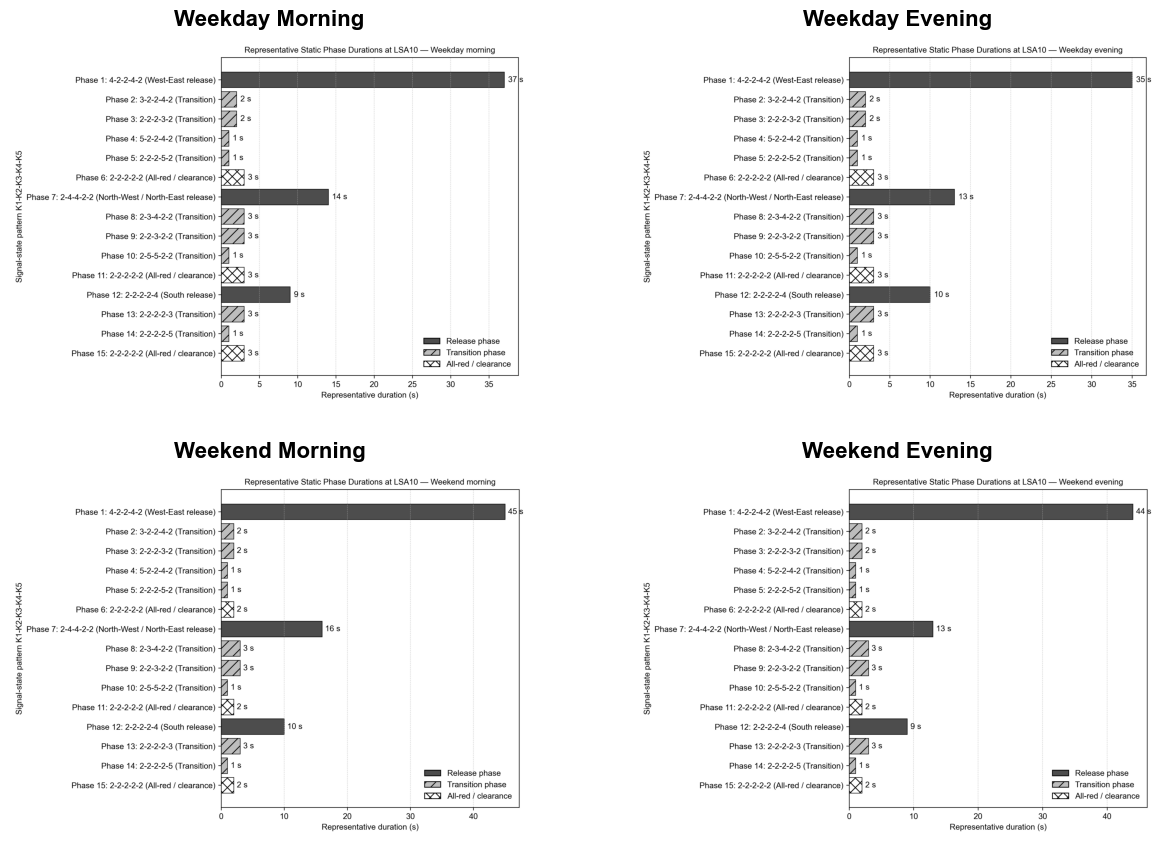

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_representative_phase_durations_combined.png


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

prefix = "LSA10_representative_phase_durations"

out_file = BASE_DIR / "LSA10_representative_phase_durations_combined.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{prefix}_{scenario}.png"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")